# Stripped 1D CNN — Raw Measurements Only, No Positional Encoding

## Hypothesis

The original CNN (`cnn.ipynb`) used 21 features per observation: 3 raw measurements + 16 sinusoidal positional encoding channels + 2 activity indicators. It achieved ROC-AUC=0.6490, worse than both the RF baseline (0.7994) and the Transformer (0.6793).

**This notebook tests whether the 16 positional encoding channels were drowning the signal.** We strip them out and feed only 4 raw measurements per observation: `rv_centered`, `rv_err`, `RHKp`, `Halpha`. The convolutions slide across observations in chronological order and learn purely from the measurement values and their local co-occurrence patterns.

## 1. Load Data & Build 4-Channel Sequences


In [1]:
# Deterministic hash ordering for set()/dict iteration across runs
import os
os.environ["PYTHONHASHSEED"] = "0"

import pandas as pd
import numpy as np

observations = pd.read_pickle('/kaggle/input/datasets/maanav0114/harps-n-dataset/observations.pkl')

FEATURE_COLS = ['rv_centered', 'rv_err', 'RHKp', 'Halpha']

def build_sequences(star_names):
    sequences = []
    for star in star_names:
        star_obs = observations[observations['star_name'] == star].sort_values('bjd')
        if len(star_obs) == 0:
            continue
        seq = star_obs[FEATURE_COLS].values.astype(np.float32)
        sequences.append(seq)
    return sequences

pos_stars = sorted(set(observations[observations['has_exoplanets'] == 1]['star_name']))
neg_stars = sorted(set(observations[observations['has_exoplanets'] == 0]['star_name']))

pos_sequences = build_sequences(pos_stars)
neg_sequences = build_sequences(neg_stars)

print(f"Positive stars: {len(pos_sequences)}, total obs: {sum(len(x) for x in pos_sequences)}")
print(f"Negative stars: {len(neg_sequences)}, total obs: {sum(len(x) for x in neg_sequences)}")
print(f"Feature dimension per observation: {pos_sequences[0].shape[1]}")
print(f"Sequence length range: {min(len(x) for x in pos_sequences + neg_sequences)}-{max(len(x) for x in pos_sequences + neg_sequences)}")


Positive stars: 413, total obs: 46533
Negative stars: 1774, total obs: 189034
Feature dimension per observation: 4
Sequence length range: 18-11469


## 2. Stratified 60/20/20 Split + Standardization


In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import random

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed = 42
seed_everything(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

MAX_SEQ_LEN = 100

# ── Change 1: partition by the SHARED star split (split.py / split.json). ──
from split import ensure_split
train_stars, val_stars, test_stars = ensure_split(observations)

star_to_seq, star_to_lab = {}, {}
for star, seq in zip(pos_stars, pos_sequences):
    star_to_seq[star], star_to_lab[star] = seq, 1
for star, seq in zip(neg_stars, neg_sequences):
    star_to_seq[star], star_to_lab[star] = seq, 0

def partition(star_list):
    seqs, labs = [], []
    for s in star_list:
        if s in star_to_seq:
            seqs.append(star_to_seq[s])
            labs.append(star_to_lab[s])
    return seqs, labs

X_train, y_train = partition(train_stars)
X_val,   y_val   = partition(val_stars)
X_test,  y_test  = partition(test_stars)

train_all = np.concatenate(X_train, axis=0)
feat_mean = train_all.mean(axis=0)
feat_std  = np.clip(train_all.std(axis=0), 1e-8, None)

def standardize(seq_list):
    return [(s - feat_mean) / feat_std for s in seq_list]

X_train = standardize(X_train)
X_val   = standardize(X_val)
X_test  = standardize(X_test)

truncate_count = 0
for seq_list in [X_train, X_val, X_test]:
    for i in range(len(seq_list)):
        if len(seq_list[i]) > MAX_SEQ_LEN:
            seq_list[i] = seq_list[i][:MAX_SEQ_LEN]
            truncate_count += 1

all_lens = [len(x) for x in X_train + X_val + X_test]
print(f"Truncated {truncate_count} stars")
print(f"Splits: train={len(X_train)} ({sum(y_train)} pos), "
      f"val={len(X_val)} ({sum(y_val)} pos), "
      f"test={len(X_test)} ({sum(y_test)} pos)")
print(f"Sequence lengths: min={min(all_lens)}, max={max(all_lens)}, "
      f"median={int(np.median(all_lens))}")


Using device: cuda
Truncated 418 stars
Splits: train=1312 (248 pos), val=437 (82 pos), test=438 (83 pos)
Sequence lengths: min=18, max=100, median=41


## 3. Dataset & Collate (Padding + Mask)


In [3]:
class StarDataset(Dataset):
    def __init__(self, sequences, labels):
        self.data = list(zip(sequences, labels))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq, label = self.data[idx]
        return torch.tensor(seq), torch.tensor(label, dtype=torch.float32)

def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = [s.shape[0] for s in sequences]
    max_len = max(lengths)
    padded = torch.zeros(len(sequences), max_len, 4)
    mask = torch.zeros(len(sequences), max_len, dtype=torch.bool)
    for i, (seq, length) in enumerate(zip(sequences, lengths)):
        padded[i, :length] = seq
        mask[i, :length] = True
    labels = torch.stack(labels)
    return padded, mask, labels

train_ds = StarDataset(X_train, y_train)
val_ds = StarDataset(X_val, y_val)
test_ds = StarDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_loader)} batches, Val: {len(val_loader)} batches, Test: {len(test_loader)} batches")
padded, mask, labels = next(iter(train_loader))
print(f"Batch shape: {padded.shape}, mask shape: {mask.shape}, labels: {labels.shape}")


Train: 41 batches, Val: 7 batches, Test: 7 batches
Batch shape: torch.Size([32, 100, 4]), mask shape: torch.Size([32, 100]), labels: torch.Size([32])


## 4. The Stripped 1D CNN Model


In [4]:
import torch.nn as nn

class MaskedConv1dBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=pad)
        self.bn   = nn.BatchNorm1d(out_ch)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.act(self.bn(self.conv(x))))

class MaskedAvgMaxPool(nn.Module):
    def forward(self, x, mask):
        m = mask.unsqueeze(1).type_as(x)
        denom = m.sum(dim=2).clamp_min(1.0)
        avg = (x * m).sum(dim=2) / denom
        masked_x = x.masked_fill(m == 0, float('-inf'))
        mx = masked_x.max(dim=2).values
        mx = torch.nan_to_num(mx, nan=0.0, posinf=0.0, neginf=0.0)
        return torch.cat([avg, mx], dim=1)

class StrippedCNN(nn.Module):
    def __init__(self, in_dim=4, hidden=64, tail=32, head_hidden=32, dropout=0.3):
        super().__init__()
        self.conv1 = MaskedConv1dBlock(in_dim,  hidden, 5, dropout)
        self.conv2 = MaskedConv1dBlock(hidden, hidden, 5, dropout)
        self.conv3 = MaskedConv1dBlock(hidden, tail,    3, dropout)
        self.pool  = MaskedAvgMaxPool()
        self.head = nn.Sequential(
            nn.Linear(2 * tail, head_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, 1),
        )

    def forward(self, x, mask):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.pool(x, mask)
        return self.head(x).squeeze(-1)

model = StrippedCNN(in_dim=4).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


StrippedCNN(
  (conv1): MaskedConv1dBlock(
    (conv): Conv1d(4, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.3, inplace=False)
  )
  (conv2): MaskedConv1dBlock(
    (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.3, inplace=False)
  )
  (conv3): MaskedConv1dBlock(
    (conv): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.3, inplace=False)
  )
  (pool): MaskedAvgMaxPool()
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.

## 5. Training Loop


In [5]:
from torch.optim import Adam
from torch.optim.lr_scheduler import LambdaLR
import math

n_pos = int(sum(y_train))
n_neg = int(len(y_train) - n_pos)
pos_weight = torch.tensor([math.sqrt(n_neg / n_pos)]).to(device)
print(f"pos_weight = {pos_weight.item():.4f}  (n_neg={n_neg}, n_pos={n_pos})")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=5e-3)

warmup_epochs = 5
max_epochs = 100

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, max_epochs - warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
best_model_state = None
patience = 15
epochs_no_improve = 0

for epoch in range(max_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for padded, mask, labels in train_loader:
        padded = padded.to(device)
        mask = mask.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(padded, mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * padded.size(0)
        preds = (logits > 0).float()
        train_correct += (preds == labels).sum().item()
        train_total += padded.size(0)

    scheduler.step()

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for padded, mask, labels in val_loader:
            padded = padded.to(device)
            mask = mask.to(device)
            labels = labels.to(device)
            logits = model(padded, mask)
            loss = criterion(logits, labels)
            val_loss += loss.item() * padded.size(0)
            preds = (logits > 0).float()
            val_correct += (preds == labels).sum().item()
            val_total += padded.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_val_loss = val_loss / val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    train_losses.append(epoch_train_loss); val_losses.append(epoch_val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        marker = " *"
    else:
        epochs_no_improve += 1
        marker = ""

    print(f"Epoch {epoch+1:3d}/{max_epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}{marker}")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}.")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Restored best model (val loss = {best_val_loss:.4f})")

torch.save(model.state_dict(), "/kaggle/working/cnn_stripped.pth")
print("Saved model to /kaggle/working/cnn_stripped.pth")


pos_weight = 2.0713  (n_neg=1064, n_pos=248)
Epoch   1/100 | Train Loss: 0.8315 Acc: 0.4360 | Val Loss: 0.8129 Acc: 0.4783 | LR: 0.000400 *
Epoch   2/100 | Train Loss: 0.7991 Acc: 0.6662 | Val Loss: 0.7907 Acc: 0.5812 | LR: 0.000600 *
Epoch   3/100 | Train Loss: 0.7761 Acc: 0.8034 | Val Loss: 0.7655 Acc: 0.8238 | LR: 0.000800 *
Epoch   4/100 | Train Loss: 0.7803 Acc: 0.8049 | Val Loss: 0.7588 Acc: 0.8307 | LR: 0.001000 *
Epoch   5/100 | Train Loss: 0.7580 Acc: 0.8110 | Val Loss: 0.7538 Acc: 0.8192 | LR: 0.001000 *
Epoch   6/100 | Train Loss: 0.7567 Acc: 0.8140 | Val Loss: 0.7577 Acc: 0.8238 | LR: 0.001000
Epoch   7/100 | Train Loss: 0.7281 Acc: 0.8140 | Val Loss: 0.7390 Acc: 0.8330 | LR: 0.000999 *
Epoch   8/100 | Train Loss: 0.7362 Acc: 0.8087 | Val Loss: 0.7312 Acc: 0.8261 | LR: 0.000998 *
Epoch   9/100 | Train Loss: 0.7239 Acc: 0.8079 | Val Loss: 0.7289 Acc: 0.8352 | LR: 0.000996 *
Epoch  10/100 | Train Loss: 0.7268 Acc: 0.8095 | Val Loss: 0.7321 Acc: 0.8238 | LR: 0.000993
Epoch  11

## 6. Training Curves


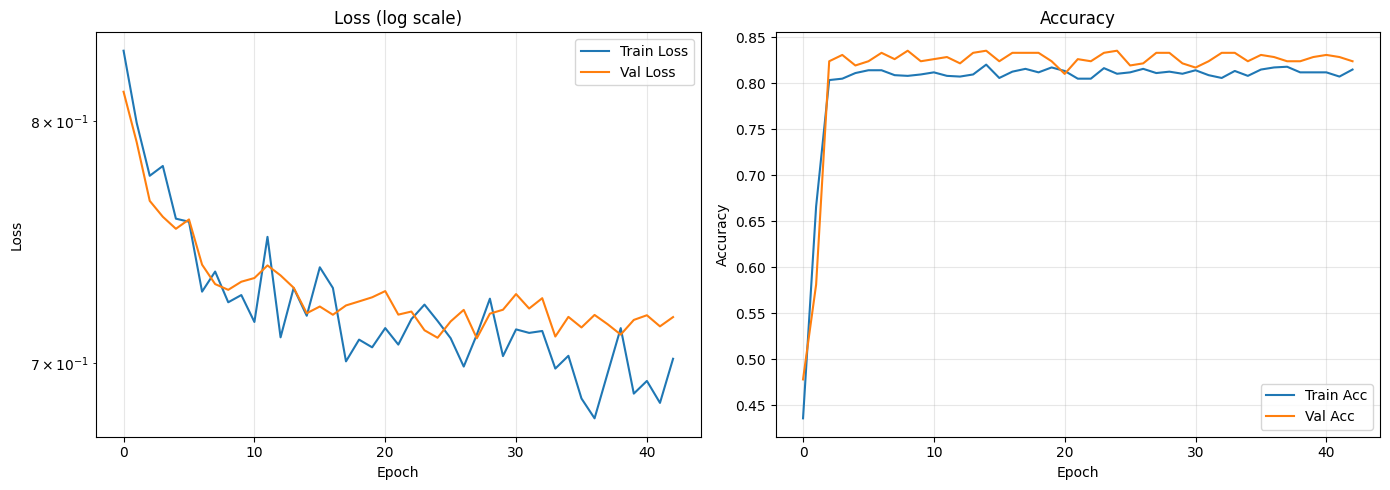

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss (log scale)')
ax1.set_yscale('log'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 7. Evaluation on the Test Set


In [7]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix)

model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for padded, mask, labels in test_loader:
        padded = padded.to(device)
        mask = mask.to(device)
        logits = model(padded, mask)
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

roc_auc = roc_auc_score(all_labels, all_probs)
pr_auc = average_precision_score(all_labels, all_probs)

# ── Change 2: select threshold on VAL, then report honest test metrics. ──
# (Previously swept PR curve on TEST and reported F1 at the test-chosen threshold
# -- biased the reported F1 optimistically.)
# 1a. VAL predictions.
val_probs, val_labels = [], []
with torch.no_grad():
    for padded, mask, labels in val_loader:
        padded = padded.to(device); mask = mask.to(device)
        probs = torch.sigmoid(model(padded, mask))
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())
val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

# 1b. Best-F1 threshold from the VAL PR curve (guarded off-by-one).
val_prec, val_rec, val_thr = precision_recall_curve(val_labels, val_probs)
val_f1 = 2 * val_prec * val_rec / (val_prec + val_rec + 1e-8)
val_best_idx = int(np.argmax(val_f1))
best_thresh = float(val_thr[val_best_idx]) if val_best_idx < len(val_thr) else 0.5

# 1c. Honest TEST metrics at the val-chosen threshold.
preds_at_thr = (all_probs >= best_thresh).astype(int)
cm_at = confusion_matrix(all_labels, preds_at_thr)
_tn, _fp, _fn, _tp = cm_at.ravel()
best_precision = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
best_recall    = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0
best_f1        = 2 * best_precision * best_recall / (best_precision + best_recall) if (best_precision + best_recall) > 0 else 0.0
val_f1_at = float(val_f1[val_best_idx]) if val_best_idx < len(val_f1) else 0.0

print(f"ROC-AUC      : {roc_auc:.4f}   (on TEST)")
print(f"PR-AUC       : {pr_auc:.4f}    (on TEST)")
print(f"Val F1       : {val_f1_at:.4f}  (threshold = {best_thresh:.4f} chosen on VAL)")
print(f"TEST F1      : {best_f1:.4f}  (at the val-chosen threshold = {best_thresh:.4f})")
print(f"  @ test F1 : precision = {best_precision:.4f}, recall = {best_recall:.4f}")


ROC-AUC      : 0.5942   (on TEST)
PR-AUC       : 0.2690    (on TEST)
Val F1       : 0.3967  (threshold = 0.3615 chosen on VAL)
TEST F1      : 0.3533  (at the val-chosen threshold = 0.3615)
  @ test F1 : precision = 0.2281, recall = 0.7831


In [8]:
# ── Change 6: bootstrap 95% CI for ROC-AUC on the TEST set. ──
# 200 resamples with replacement, percentile method [2.5, 97.5], seed=42.
# All inter-model comparisons in this project finally become comparable: each
# ROC-AUC point estimate now carries an honest uncertainty band computed on the
# SAME shared test split (split.py).
from split import bootstrap_roc_auc
_point, _lo, _hi = bootstrap_roc_auc(all_labels, all_probs, n_resamples=200, seed=42)
print(f"[Stripped CNN]  ROC-AUC: {_point:.4f} (95% CI: [{_lo:.4f}, {_hi:.4f}])")


[Stripped CNN]  ROC-AUC: 0.5942 (95% CI: [0.5307, 0.6595])


### Confusion Matrix at Best-F1 Threshold


In [9]:
preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, preds)
print(f"Confusion Matrix (threshold = {best_thresh:.3f}):")
print(cm)
print(f"\n  True Negatives:  {cm[0,0]}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")
print(f"  True Positives:  {cm[1,1]}")


Confusion Matrix (threshold = 0.361):
[[135 220]
 [ 18  65]]

  True Negatives:  135
  False Positives: 220
  False Negatives: 18
  True Positives:  65


## 8. Comparison with Other Models


In [10]:
import pandas as pd

comparison = pd.DataFrame([
    {"Model": "RF (16 physical features)",       "Input": "per-star aggregates",  "ROC-AUC": 0.7994,  "PR-AUC": 0.4658,  "Best F1": 0.5221},
    {"Model": "Transformer (raw sequences)",     "Input": "(T, 21) raw obs",      "ROC-AUC": 0.6793,  "PR-AUC": float('nan'),  "Best F1": float('nan')},
    {"Model": "CNN + pos encoding (21 ch)",      "Input": "(T, 21) raw obs",      "ROC-AUC": 0.6490,  "PR-AUC": 0.3049,  "Best F1": 0.3887},
    {"Model": "CNN stripped (4 ch, this nb)",     "Input": "(T, 4) raw obs",       "ROC-AUC": roc_auc, "PR-AUC": pr_auc,         "Best F1": best_f1},
])

print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
if roc_auc > 0.7994:
    print(f"* Stripped CNN ({roc_auc:.4f}) BEATS the RF baseline (0.7994).")
elif roc_auc > 0.6793:
    print(f"* Stripped CNN ({roc_auc:.4f}) beats the Transformer (0.6793) but trails the RF (0.7994).")
elif roc_auc > 0.6490:
    print(f"* Stripped CNN ({roc_auc:.4f}) beats the original CNN with pos encoding (0.6490).")
else:
    print(f"* Stripped CNN ({roc_auc:.4f}) trails all baselines.")


                       Model               Input  ROC-AUC  PR-AUC  Best F1
   RF (16 physical features) per-star aggregates   0.7994  0.4658   0.5221
 Transformer (raw sequences)     (T, 21) raw obs   0.6793     NaN      NaN
  CNN + pos encoding (21 ch)     (T, 21) raw obs   0.6490  0.3049   0.3887
CNN stripped (4 ch, this nb)      (T, 4) raw obs   0.5942  0.2690   0.3533

* Stripped CNN (0.5942) trails all baselines.
